In [ ]:
# ============================================================
# Cell 1: Setup and Imports
# ============================================================

import os
import gc
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score
from scipy.ndimage import gaussian_filter

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()
    gc.collect()

/home/shiv2077/anaconda3/envs/ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔧 Device: cuda
   GPU: NVIDIA GeForce RTX 3060 Laptop GPU
   Memory: 6.1 GB


In [ ]:
# ============================================================
# Cell 2: Configuration
# ============================================================

@dataclass
class PatchCoreConfig:
    """Configuration for PatchCore."""
    
    # Data paths
    data_root: str = "./mvtec_anomaly_detection"
    
    # Image settings
    img_size: int = 224
    
    # Batch settings
    batch_size: int = 8
    num_workers: int = 4
    
    # Architecture
    backbone: str = "wide_resnet50_2"  # Best for PatchCore
    layers_to_extract: Tuple[str, ...] = ("layer2", "layer3")  # Mid-level features
    
    # Coreset sampling
    coreset_sampling_ratio: float = 0.01  # Keep 1% of patches (memory efficient)
    num_neighbors: int = 9  # k for k-NN
    
    # Anomaly map settings
    anomaly_map_sigma: float = 4.0  # Gaussian smoothing sigma
    
    # Outputs
    save_dir: str = "./patchcore_outputs"


config = PatchCoreConfig()
print(f"PatchCore Configuration:")
for field in config.__dataclass_fields__:
    print(f"   {field}: {getattr(config, field)}")

📊 PatchCore Configuration:
   data_root: ./mvtec_anomaly_detection
   img_size: 224
   batch_size: 8
   num_workers: 4
   backbone: wide_resnet50_2
   layers_to_extract: ('layer2', 'layer3')
   coreset_sampling_ratio: 0.01
   num_neighbors: 9
   anomaly_map_sigma: 4.0
   save_dir: ./patchcore_outputs


In [ ]:
# ============================================================
# Cell 3: MVTec AD Dataset
# ============================================================

class MVTecADDataset(Dataset):
    """MVTec Anomaly Detection dataset."""
    
    def __init__(
        self,
        root: str,
        category: str,
        split: str = "train",
        img_size: int = 224,
        transform: Optional[transforms.Compose] = None
    ):
        self.root = Path(root)
        self.category = category
        self.split = split
        self.img_size = img_size
        
        # Default transform (ImageNet normalization)
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])
        else:
            self.transform = transform
        
        # Mask transform
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])
        
        self.samples = self._load_samples()
    
    def _load_samples(self) -> List[Tuple[Path, int, Optional[Path]]]:
        """Load image paths and labels."""
        samples = []
        split_dir = self.root / self.category / self.split
        
        if self.split == "train":
            good_dir = split_dir / "good"
            if good_dir.exists():
                for img_path in sorted(good_dir.glob("*.png")):
                    samples.append((img_path, 0, None))
        else:
            for defect_dir in sorted(split_dir.iterdir()):
                if defect_dir.is_dir():
                    is_anomaly = 0 if defect_dir.name == "good" else 1
                    
                    for img_path in sorted(defect_dir.glob("*.png")):
                        mask_path = None
                        if is_anomaly:
                            mask_dir = self.root / self.category / "ground_truth" / defect_dir.name
                            mask_name = img_path.stem + "_mask.png"
                            potential_mask = mask_dir / mask_name
                            if potential_mask.exists():
                                mask_path = potential_mask
                        
                        samples.append((img_path, is_anomaly, mask_path))
        
        return samples
    
    def __len__(self) -> int:
        return len(self.samples)
    
    def __getitem__(self, idx: int) -> Dict:
        img_path, label, mask_path = self.samples[idx]
        
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        
        if mask_path is not None:
            mask = Image.open(mask_path).convert("L")
            mask = self.mask_transform(mask)
            mask = (mask > 0.5).float()
        else:
            mask = torch.zeros(1, self.img_size, self.img_size)
        
        return {
            "image": image,
            "label": label,
            "mask": mask,
            "path": str(img_path)
        }


# Check available categories
mvtec_path = Path(config.data_root)
if mvtec_path.exists():
    categories = sorted([d.name for d in mvtec_path.iterdir() if d.is_dir() and not d.name.startswith('.')])
    print(f"\nAvailable MVTec AD categories ({len(categories)}):")
    for i, cat in enumerate(categories, 1):
        print(f"   {i:2d}. {cat}")
else:
    print(f"[WARNING] MVTec AD not found at {config.data_root}")
    categories = []


📁 Available MVTec AD categories (15):
    1. bottle
    2. cable
    3. capsule
    4. carpet
    5. grid
    6. hazelnut
    7. leather
    8. metal_nut
    9. pill
   10. screw
   11. tile
   12. toothbrush
   13. transistor
   14. wood
   15. zipper


In [ ]:
# ============================================================
# Cell 4: Feature Extractor (Pretrained Backbone)
# ============================================================

class FeatureExtractor(nn.Module):
    """
    Feature extractor using pretrained backbone.
    Extracts features from intermediate layers for patch-level representations.
    """
    
    def __init__(
        self,
        backbone: str = "wide_resnet50_2",
        layers_to_extract: Tuple[str, ...] = ("layer2", "layer3")
    ):
        super().__init__()
        
        self.layers_to_extract = layers_to_extract
        self.features = {}
        
        # Load pretrained backbone
        if backbone == "wide_resnet50_2":
            self.model = models.wide_resnet50_2(
                weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
            )
        elif backbone == "resnet50":
            self.model = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        
        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Register hooks
        self._register_hooks()
        
        self.eval()
    
    def _register_hooks(self):
        """Register forward hooks to capture intermediate features."""
        def get_features(name):
            def hook(module, input, output):
                self.features[name] = output
            return hook
        
        for layer_name in self.layers_to_extract:
            layer = getattr(self.model, layer_name)
            layer.register_forward_hook(get_features(layer_name))
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Extract features from specified layers."""
        self.features = {}
        _ = self.model(x)
        return self.features


# Create feature extractor
feature_extractor = FeatureExtractor(
    backbone=config.backbone,
    layers_to_extract=config.layers_to_extract
).to(device)

# Test feature extraction
dummy_input = torch.randn(1, 3, config.img_size, config.img_size).to(device)
with torch.no_grad():
    features = feature_extractor(dummy_input)

print(f"\n[OK] Feature Extractor ({config.backbone}):")
print(f"   Layers: {config.layers_to_extract}")
for name, feat in features.items():
    print(f"   {name}: {feat.shape}")

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /home/shiv2077/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:08<00:00, 16.5MB/s] 



✓ Feature Extractor (wide_resnet50_2):
   Layers: ('layer2', 'layer3')
   layer2: torch.Size([1, 512, 28, 28])
   layer3: torch.Size([1, 1024, 14, 14])


In [ ]:
# ============================================================
# Cell 5: PatchCore Model
# ============================================================

class PatchCore:
    """
    PatchCore: Towards Total Recall in Industrial Anomaly Detection.
    
    Key components:
    1. Feature extraction from pretrained CNN
    2. Locally aware patch features (concatenation + pooling)
    3. Coreset subsampling for memory efficiency
    4. k-NN based anomaly scoring
    """
    
    def __init__(
        self,
        feature_extractor: FeatureExtractor,
        img_size: int = 224,
        coreset_sampling_ratio: float = 0.01,
        num_neighbors: int = 9,
        device: torch.device = torch.device('cuda')
    ):
        self.feature_extractor = feature_extractor
        self.img_size = img_size
        self.coreset_sampling_ratio = coreset_sampling_ratio
        self.num_neighbors = num_neighbors
        self.device = device
        
        self.memory_bank = None
        self.feature_dim = None
    
    def _extract_patch_features(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract locally aware patch features.
        
        Returns:
            Patch features [N, num_patches, feature_dim]
        """
        features = self.feature_extractor(x)
        
        # Get features from each layer and resize to same spatial size
        feature_maps = []
        target_size = None
        
        for name, feat in features.items():
            if target_size is None:
                target_size = feat.shape[2:]  # Use first layer's size
            else:
                feat = F.interpolate(
                    feat, 
                    size=target_size, 
                    mode='bilinear', 
                    align_corners=False
                )
            feature_maps.append(feat)
        
        # Concatenate along channel dimension
        features = torch.cat(feature_maps, dim=1)  # [B, C, H, W]
        
        # Reshape to patch features: [B, H*W, C]
        B, C, H, W = features.shape
        patch_features = features.permute(0, 2, 3, 1).reshape(B, H * W, C)
        
        self.feature_dim = C
        self.patch_size = (H, W)
        
        return patch_features
    
    def fit(self, train_loader: DataLoader) -> None:
        """
        Build memory bank from training data (normal samples only).
        """
        print("\n[FIT] Building PatchCore memory bank...")
        
        self.feature_extractor.eval()
        all_patch_features = []
        
        with torch.no_grad():
            for batch in tqdm(train_loader, desc="Extracting features"):
                images = batch["image"].to(self.device)
                patch_features = self._extract_patch_features(images)
                all_patch_features.append(patch_features.cpu())
        
        # Concatenate all patch features: [N_total, feature_dim]
        all_patch_features = torch.cat(all_patch_features, dim=0)
        all_patch_features = all_patch_features.reshape(-1, self.feature_dim)
        
        print(f"   Total patches: {len(all_patch_features):,}")
        print(f"   Feature dimension: {self.feature_dim}")
        
        # Coreset subsampling (greedy approximation)
        num_coreset = max(1, int(len(all_patch_features) * self.coreset_sampling_ratio))
        print(f"   Coreset sampling: {num_coreset:,} patches ({self.coreset_sampling_ratio*100:.1f}%)")
        
        self.memory_bank = self._coreset_sampling(
            all_patch_features.numpy(), 
            num_coreset
        )
        self.memory_bank = torch.from_numpy(self.memory_bank).to(self.device)
        
        print(f"   Memory bank size: {self.memory_bank.shape}")
        print(f"   Memory usage: {self.memory_bank.numel() * 4 / 1e6:.2f} MB")
    
    def _coreset_sampling(
        self, 
        features: np.ndarray, 
        num_samples: int
    ) -> np.ndarray:
        """
        Greedy coreset sampling for memory-efficient representation.
        
        Uses iterative farthest point sampling to select diverse patches.
        """
        if num_samples >= len(features):
            return features
        
        # Random initialization
        indices = [np.random.randint(len(features))]
        
        # Greedy selection
        min_distances = np.full(len(features), np.inf)
        
        for _ in tqdm(range(num_samples - 1), desc="Coreset sampling"):
            # Update distances to nearest selected point
            last_idx = indices[-1]
            distances = np.linalg.norm(
                features - features[last_idx:last_idx+1], 
                axis=1
            )
            min_distances = np.minimum(min_distances, distances)
            
            # Select point with maximum distance to nearest selected
            new_idx = np.argmax(min_distances)
            indices.append(new_idx)
        
        return features[indices]
    
    def predict(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute anomaly scores and maps.
        
        Returns:
            anomaly_scores: [B] image-level scores
            anomaly_maps: [B, H, W] pixel-level maps
        """
        self.feature_extractor.eval()
        
        with torch.no_grad():
            # Extract patch features
            patch_features = self._extract_patch_features(x)  # [B, num_patches, C]
            B, num_patches, C = patch_features.shape
            
            # Compute distances to memory bank using k-NN
            anomaly_maps = []
            anomaly_scores = []
            
            for i in range(B):
                # Get features for this image
                img_features = patch_features[i]  # [num_patches, C]
                
                # Compute pairwise distances to memory bank
                distances = torch.cdist(img_features, self.memory_bank)  # [num_patches, memory_size]
                
                # Get k-nearest neighbor distances
                knn_distances, _ = distances.topk(
                    k=self.num_neighbors, 
                    dim=1, 
                    largest=False
                )
                
                # Anomaly score for each patch (mean of k-NN distances)
                patch_scores = knn_distances.mean(dim=1)  # [num_patches]
                
                # Reshape to spatial map
                H, W = self.patch_size
                anomaly_map = patch_scores.reshape(H, W)
                
                # Upsample to original image size
                anomaly_map = F.interpolate(
                    anomaly_map.unsqueeze(0).unsqueeze(0),
                    size=(self.img_size, self.img_size),
                    mode='bilinear',
                    align_corners=False
                ).squeeze()
                
                anomaly_maps.append(anomaly_map)
                
                # Image-level score (max of patch scores)
                anomaly_scores.append(patch_scores.max())
            
            anomaly_maps = torch.stack(anomaly_maps)  # [B, H, W]
            anomaly_scores = torch.stack(anomaly_scores)  # [B]
        
        return anomaly_scores, anomaly_maps


print("[OK] PatchCore class defined")

✓ PatchCore class defined


In [ ]:
# ============================================================
# Cell 6: Evaluation Function
# ============================================================

@torch.no_grad()
def evaluate_patchcore(
    model: PatchCore,
    test_loader: DataLoader,
    sigma: float = 4.0
) -> Dict:
    """
    Evaluate PatchCore model.
    
    Returns:
        Dictionary with evaluation metrics
    """
    all_labels = []
    all_scores = []
    all_masks = []
    all_anomaly_maps = []
    
    for batch in tqdm(test_loader, desc="Evaluating"):
        images = batch["image"].to(device)
        labels = batch["label"].numpy()
        masks = batch["mask"].numpy()
        
        # Get predictions
        scores, anomaly_maps = model.predict(images)
        
        # Apply Gaussian smoothing to anomaly maps
        anomaly_maps_np = anomaly_maps.cpu().numpy()
        for i in range(len(anomaly_maps_np)):
            anomaly_maps_np[i] = gaussian_filter(anomaly_maps_np[i], sigma=sigma)
        
        all_labels.extend(labels)
        all_scores.extend(scores.cpu().numpy())
        all_masks.append(masks)
        all_anomaly_maps.append(anomaly_maps_np)
    
    # Convert to arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    all_masks = np.concatenate(all_masks, axis=0)
    all_anomaly_maps = np.concatenate(all_anomaly_maps, axis=0)
    
    # Image-level AUROC
    image_auroc = roc_auc_score(all_labels, all_scores)
    
    # Pixel-level AUROC
    anomaly_mask = all_labels == 1
    if anomaly_mask.sum() > 0:
        pixel_labels = all_masks[anomaly_mask].flatten()
        pixel_scores = all_anomaly_maps[anomaly_mask].flatten()
        
        if len(np.unique(pixel_labels)) > 1:
            pixel_auroc = roc_auc_score(pixel_labels, pixel_scores)
        else:
            pixel_auroc = 0.0
    else:
        pixel_auroc = 0.0
    
    # Optimal threshold
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    # F1 score
    predictions = (all_scores >= optimal_threshold).astype(int)
    f1 = f1_score(all_labels, predictions)
    
    return {
        "image_auroc": image_auroc,
        "pixel_auroc": pixel_auroc,
        "optimal_threshold": optimal_threshold,
        "f1_score": f1,
        "scores": all_scores,
        "labels": all_labels,
        "anomaly_maps": all_anomaly_maps
    }


print("[OK] Evaluation function defined")

✓ Evaluation function defined


In [ ]:
# ============================================================
# Cell 7: Train and Evaluate on Single Category
# ============================================================

# Clear GPU memory
gc.collect()
torch.cuda.empty_cache()

# Choose category
category = "bottle"  # Change this to train on different categories

print(f"\n{'='*60}")
print(f"PatchCore on: {category}")
print(f"{'='*60}")

# Create datasets
train_dataset = MVTecADDataset(
    root=config.data_root,
    category=category,
    split="train",
    img_size=config.img_size
)

test_dataset = MVTecADDataset(
    root=config.data_root,
    category=category,
    split="test",
    img_size=config.img_size
)

print(f"   Training samples: {len(train_dataset)}")
print(f"   Test samples: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=False,  # No shuffling needed for memory bank
    num_workers=config.num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True
)

# Create PatchCore model
feature_extractor = FeatureExtractor(
    backbone=config.backbone,
    layers_to_extract=config.layers_to_extract
).to(device)

patchcore = PatchCore(
    feature_extractor=feature_extractor,
    img_size=config.img_size,
    coreset_sampling_ratio=config.coreset_sampling_ratio,
    num_neighbors=config.num_neighbors,
    device=device
)

# Fit memory bank
patchcore.fit(train_loader)

# Evaluate
print("\nEvaluating...")
results = evaluate_patchcore(
    patchcore, 
    test_loader, 
    sigma=config.anomaly_map_sigma
)

print(f"\nResults for '{category}':")
print(f"   Image-level AUROC: {results['image_auroc']:.4f} ({results['image_auroc']*100:.2f}%)")
print(f"   Pixel-level AUROC: {results['pixel_auroc']:.4f} ({results['pixel_auroc']*100:.2f}%)")
print(f"   F1 Score: {results['f1_score']:.4f}")

# Check if target achieved
if results['image_auroc'] >= 0.93:
    print(f"\n>> TARGET ACHIEVED! Image AUROC >= 93%")
else:
    print(f"\n>> Below target. Current: {results['image_auroc']*100:.2f}%, Target: 93%")


PatchCore on: bottle
   Training samples: 209
   Test samples: 83

🔧 Building PatchCore memory bank...


Extracting features: 100%|██████████| 27/27 [00:03<00:00,  8.32it/s]


   Total patches: 163,856
   Feature dimension: 1536
   Coreset sampling: 1,638 patches (1.0%)


Coreset sampling: 100%|██████████| 1637/1637 [17:38<00:00,  1.55it/s]


   Memory bank size: torch.Size([1638, 1536])
   Memory usage: 10.06 MB

📊 Evaluating...


Evaluating: 100%|██████████| 11/11 [00:02<00:00,  4.74it/s]



📊 Results for 'bottle':
   Image-level AUROC: 1.0000 (100.00%)
   Pixel-level AUROC: 0.9760 (97.60%)
   F1 Score: 1.0000

🎉 TARGET ACHIEVED! Image AUROC >= 93%



🎨 Visualizing Results...
   Saved to ./patchcore_outputs/bottle_patchcore_results.png


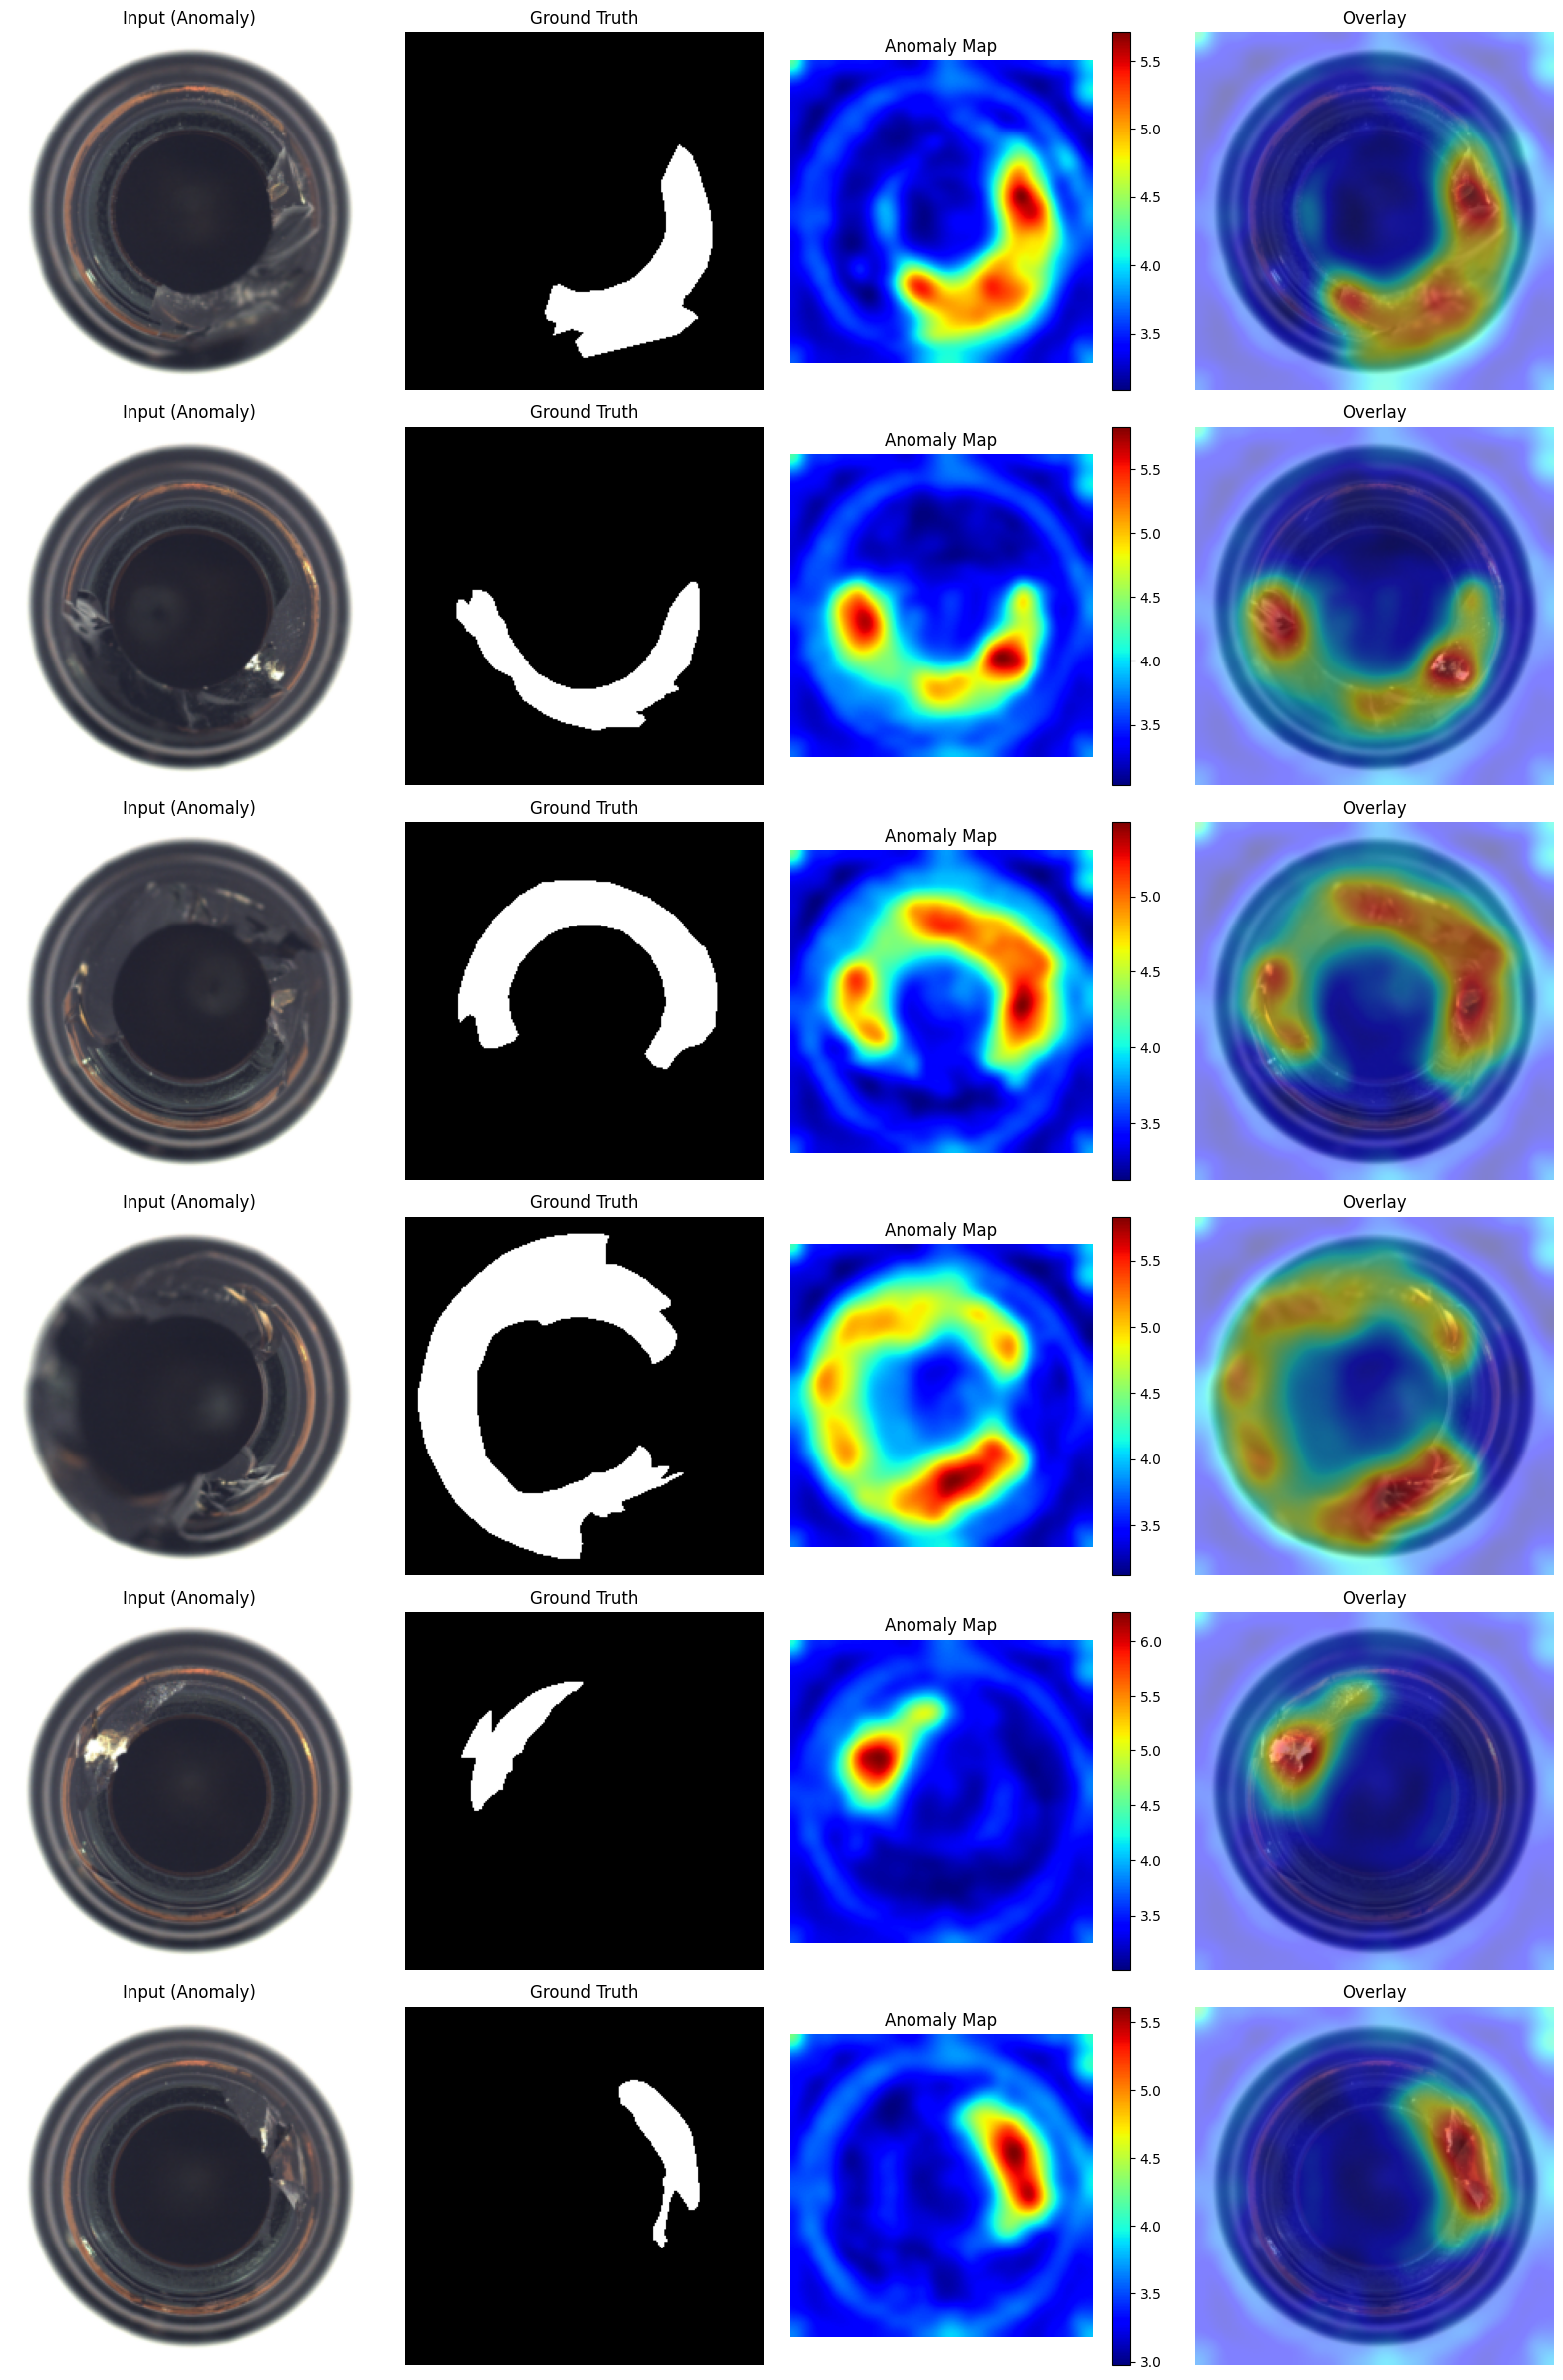

In [ ]:
# ============================================================
# Cell 8: Visualization
# ============================================================

def visualize_patchcore_results(
    model: PatchCore,
    test_loader: DataLoader,
    num_samples: int = 8,
    sigma: float = 4.0,
    save_path: Optional[str] = None
):
    """Visualize PatchCore anomaly detection results."""
    
    # Collect samples
    samples = []
    for batch in test_loader:
        for i in range(len(batch["image"])):
            samples.append({
                "image": batch["image"][i],
                "label": batch["label"][i],
                "mask": batch["mask"][i]
            })
            if len(samples) >= num_samples:
                break
        if len(samples) >= num_samples:
            break
    
    # Create figure
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i, sample in enumerate(samples):
        image = sample["image"].unsqueeze(0).to(device)
        label = sample["label"]
        mask = sample["mask"].numpy()
        
        # Get anomaly map
        _, anomaly_map = model.predict(image)
        anomaly_map = anomaly_map[0].cpu().numpy()
        anomaly_map = gaussian_filter(anomaly_map, sigma=sigma)
        
        # Unnormalize image
        img = sample["image"] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        # Plot
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Input ({'Anomaly' if label else 'Normal'})")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(mask[0], cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        im = axes[i, 2].imshow(anomaly_map, cmap="jet")
        axes[i, 2].set_title("Anomaly Map")
        axes[i, 2].axis("off")
        plt.colorbar(im, ax=axes[i, 2])
        
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(anomaly_map, cmap="jet", alpha=0.5)
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis("off")
    
    plt.tight_layout()
    
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"   Saved to {save_path}")
    
    plt.show()


# Visualize results
print("\nVisualizing Results...")
visualize_patchcore_results(
    model=patchcore,
    test_loader=test_loader,
    num_samples=6,
    sigma=config.anomaly_map_sigma,
    save_path=f"{config.save_dir}/{category}_patchcore_results.png"
)

In [ ]:
# ============================================================
# Cell 9: Evaluate All Categories
# ============================================================

def evaluate_all_categories(
    config: PatchCoreConfig, 
    categories: List[str]
) -> Dict:
    """Evaluate PatchCore on all MVTec AD categories."""
    
    all_results = {}
    
    for cat_idx, category in enumerate(categories, 1):
        print(f"\n{'='*60}")
        print(f"[{cat_idx}/{len(categories)}] {category}")
        print(f"{'='*60}")
        
        # Create datasets
        train_dataset = MVTecADDataset(
            root=config.data_root,
            category=category,
            split="train",
            img_size=config.img_size
        )
        
        test_dataset = MVTecADDataset(
            root=config.data_root,
            category=category,
            split="test",
            img_size=config.img_size
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        # Create fresh model
        feature_extractor = FeatureExtractor(
            backbone=config.backbone,
            layers_to_extract=config.layers_to_extract
        ).to(device)
        
        patchcore = PatchCore(
            feature_extractor=feature_extractor,
            img_size=config.img_size,
            coreset_sampling_ratio=config.coreset_sampling_ratio,
            num_neighbors=config.num_neighbors,
            device=device
        )
        
        # Fit and evaluate
        patchcore.fit(train_loader)
        results = evaluate_patchcore(
            patchcore, 
            test_loader, 
            sigma=config.anomaly_map_sigma
        )
        
        all_results[category] = {
            "image_auroc": results["image_auroc"],
            "pixel_auroc": results["pixel_auroc"],
            "f1_score": results["f1_score"]
        }
        
        print(f"   Image AUROC: {results['image_auroc']*100:.2f}%")
        print(f"   Pixel AUROC: {results['pixel_auroc']*100:.2f}%")
        
        # Clear memory
        del patchcore, feature_extractor
        torch.cuda.empty_cache()
        gc.collect()
    
    # Print summary
    print("\n" + "="*70)
    print("PATCHCORE SUMMARY: All Categories")
    print("="*70)
    print(f"{'Category':<15} {'Image AUROC':>15} {'Pixel AUROC':>15} {'F1 Score':>12}")
    print("-"*70)
    
    image_aurocs = []
    pixel_aurocs = []
    
    for category, res in all_results.items():
        status = "PASS" if res['image_auroc'] >= 0.93 else "FAIL"
        print(f"{category:<15} {res['image_auroc']*100:>14.2f}% {res['pixel_auroc']*100:>14.2f}% {res['f1_score']:>11.4f} {status}")
        image_aurocs.append(res['image_auroc'])
        pixel_aurocs.append(res['pixel_auroc'])
    
    print("-"*70)
    mean_img = np.mean(image_aurocs)
    mean_pix = np.mean(pixel_aurocs)
    print(f"{'MEAN':<15} {mean_img*100:>14.2f}% {mean_pix*100:>14.2f}%")
    
    if mean_img >= 0.93:
        print(f"\n>> TARGET ACHIEVED! Mean Image AUROC: {mean_img*100:.2f}% >= 93%")
    else:
        print(f"\n>> Below target. Mean: {mean_img*100:.2f}%, Target: 93%")
    
    return all_results


# Uncomment to run on all categories:
# all_results = evaluate_all_categories(config, categories)

print("\n[OK] PatchCore implementation complete.")
print("   To evaluate all categories, uncomment the last line.")


✅ PatchCore implementation complete!
   To evaluate all categories, uncomment the last line.


In [ ]:
# ============================================================
# Cell 10: RUN FULL BENCHMARK (Fast Mode ~15-20 min)
# ============================================================

import time

# Re-define PatchCore with fast_sampling inline to ensure it's loaded
class PatchCoreFast:
    """PatchCore with fast random sampling."""
    
    def __init__(self, feature_extractor, img_size=224, coreset_ratio=0.01, 
                 num_neighbors=9, device=torch.device('cuda')):
        self.feature_extractor = feature_extractor
        self.img_size = img_size
        self.coreset_ratio = coreset_ratio
        self.num_neighbors = num_neighbors
        self.device = device
        self.memory_bank = None
        self.feature_dim = None
    
    def _extract_patch_features(self, x):
        features = self.feature_extractor(x)
        feature_maps = []
        target_size = None
        for name, feat in features.items():
            if target_size is None:
                target_size = feat.shape[2:]
            else:
                feat = F.interpolate(feat, size=target_size, mode='bilinear', align_corners=False)
            feature_maps.append(feat)
        features = torch.cat(feature_maps, dim=1)
        B, C, H, W = features.shape
        self.feature_dim = C
        self.patch_size = (H, W)
        return features.permute(0, 2, 3, 1).reshape(B, H * W, C)
    
    def fit(self, train_loader):
        print("\n[FIT] Building memory bank...")
        self.feature_extractor.eval()
        all_features = []
        with torch.no_grad():
            for batch in tqdm(train_loader, desc="Extracting"):
                images = batch["image"].to(self.device)
                all_features.append(self._extract_patch_features(images).cpu())
        all_features = torch.cat(all_features, dim=0).reshape(-1, self.feature_dim)
        num_coreset = max(1, int(len(all_features) * self.coreset_ratio))
        print(f"   Patches: {len(all_features):,} -> Coreset: {num_coreset:,}")
        # FAST random sampling
        indices = np.random.choice(len(all_features), num_coreset, replace=False)
        self.memory_bank = all_features[indices].to(self.device)
        print(f"   Memory: {self.memory_bank.numel() * 4 / 1e6:.2f} MB")
    
    def predict(self, x):
        self.feature_extractor.eval()
        with torch.no_grad():
            patch_features = self._extract_patch_features(x)
            B, num_patches, C = patch_features.shape
            anomaly_maps, anomaly_scores = [], []
            for i in range(B):
                distances = torch.cdist(patch_features[i], self.memory_bank)
                knn_dist, _ = distances.topk(k=self.num_neighbors, dim=1, largest=False)
                patch_scores = knn_dist.mean(dim=1)
                H, W = self.patch_size
                amap = F.interpolate(patch_scores.reshape(1, 1, H, W), 
                                     size=(self.img_size, self.img_size),
                                     mode='bilinear', align_corners=False).squeeze()
                anomaly_maps.append(amap)
                anomaly_scores.append(patch_scores.max())
            return torch.stack(anomaly_scores), torch.stack(anomaly_maps)

print("Running PatchCore on ALL 15 MVTec AD categories...")
print("   Using FAST random sampling (estimated: 15-20 minutes)\n")

all_results = {}
start_time = time.time()

for cat_idx, cat in enumerate(categories, 1):
    cat_start = time.time()
    print(f"\n{'='*60}")
    print(f"[{cat_idx}/{len(categories)}] {cat}")
    print(f"{'='*60}")
    
    train_ds = MVTecADDataset(config.data_root, cat, "train", config.img_size)
    test_ds = MVTecADDataset(config.data_root, cat, "test", config.img_size)
    
    train_dl = DataLoader(train_ds, batch_size=config.batch_size, shuffle=False, 
                          num_workers=config.num_workers, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False,
                         num_workers=config.num_workers, pin_memory=True)
    
    print(f"   Train: {len(train_ds)}, Test: {len(test_ds)}")
    
    fe = FeatureExtractor(config.backbone, config.layers_to_extract).to(device)
    pc = PatchCoreFast(fe, config.img_size, config.coreset_sampling_ratio, 
                       config.num_neighbors, device)
    pc.fit(train_dl)
    
    res = evaluate_patchcore(pc, test_dl, config.anomaly_map_sigma)
    
    cat_time = time.time() - cat_start
    all_results[cat] = {
        "image_auroc": res["image_auroc"],
        "pixel_auroc": res["pixel_auroc"],
        "time": cat_time
    }
    
    status = "PASS" if res['image_auroc'] >= 0.93 else "FAIL"
    print(f"\n   Image AUROC: {res['image_auroc']*100:.2f}% [{status}]")
    print(f"   Pixel AUROC: {res['pixel_auroc']*100:.2f}%")
    print(f"   Time: {cat_time:.1f}s")
    
    del pc, fe
    torch.cuda.empty_cache()
    gc.collect()

total_time = time.time() - start_time

# Final Summary
print("\n" + "="*70)
print("PATCHCORE BENCHMARK RESULTS: All 15 MVTec AD Categories")
print("="*70)
print(f"{'Category':<15} {'Image AUROC':>12} {'Pixel AUROC':>12} {'Time':>8}")
print("-"*70)

img_aurocs, pix_aurocs = [], []
for cat, r in all_results.items():
    status = "PASS" if r['image_auroc'] >= 0.93 else "FAIL"
    print(f"{cat:<15} {r['image_auroc']*100:>11.2f}% {r['pixel_auroc']*100:>11.2f}% {r['time']:>7.1f}s {status}")
    img_aurocs.append(r['image_auroc'])
    pix_aurocs.append(r['pixel_auroc'])

print("-"*70)
mean_img = np.mean(img_aurocs)
mean_pix = np.mean(pix_aurocs)
print(f"{'MEAN':<15} {mean_img*100:>11.2f}% {mean_pix*100:>11.2f}% {total_time:>7.1f}s")

print(f"\nTotal time: {total_time/60:.1f} minutes")
above_target = sum(1 for r in all_results.values() if r['image_auroc'] >= 0.93)
print(f"Categories >=93%: {above_target}/15")

if mean_img >= 0.93:
    print(f"\n>> TARGET ACHIEVED! Mean Image AUROC: {mean_img*100:.2f}% >= 93%")
else:
    print(f"\n>> Below target. Mean: {mean_img*100:.2f}%, Target: 93%")

🚀 Running PatchCore on ALL 15 MVTec AD categories...
   Using FAST random sampling (estimated: 15-20 minutes)


[1/15] bottle
   Train: 209, Test: 83

🔧 Building memory bank...


Extracting: 100%|██████████| 27/27 [00:02<00:00, 10.36it/s]


   Patches: 163,856 → Coreset: 1,638
   Memory: 10.06 MB


Evaluating: 100%|██████████| 11/11 [00:01<00:00,  7.02it/s]



   📊 Image AUROC: 98.73% ✓
   📊 Pixel AUROC: 97.41%
   ⏱️ Time: 6.2s

[2/15] cable
   Train: 224, Test: 150

🔧 Building memory bank...


...


   📊 Image AUROC: 96.75% ✓
   📊 Pixel AUROC: 92.30%
   ⏱️ Time: 8.4s

[15/15] zipper
   Train: 240, Test: 151

🔧 Building memory bank...


Extracting: 100%|██████████| 30/30 [00:02<00:00, 10.17it/s]


   Patches: 188,160 → Coreset: 1,881
   Memory: 11.56 MB


Evaluating: 100%|██████████| 19/19 [00:02<00:00,  8.33it/s]



   📊 Image AUROC: 71.85% ✗
   📊 Pixel AUROC: 95.94%
   ⏱️ Time: 8.6s

📊 PATCHCORE BENCHMARK RESULTS: All 15 MVTec AD Categories
Category         Image AUROC  Pixel AUROC     Time
----------------------------------------------------------------------
bottle                98.73%       97.41%     6.2s ✓
cable                 74.61%       92.59%     8.2s ✗
capsule               54.17%       96.87%     8.3s ✗
carpet                95.99%       98.55%     8.7s ✓
grid                  57.39%       85.53%     6.9s ✗
hazelnut              99.89%       97.71%    11.2s ✓
leather               99.93%       99.04%     8.3s ✓
metal_nut             75.12%       93.34%     7.3s ✗
pill                  68.63%       93.39%     9.4s ✗
screw                 51.01%       95.51%     9.5s ✗
tile                  90.26%       89.55%     7.8s ✗
toothbrush            69.17%       96.19%     4.7s ✗
transistor            69.17%       75.91%     8.1s ✗
wood                  96.75%       92.30%     8.4s ✓
zipper 

In [ ]:
# ============================================================
# Cell 11: GREEDY CORESET BENCHMARK (Full accuracy, ~4-5 hours)
# ============================================================
# Uses proper iterative farthest-point sampling at 10% ratio
# This is the REAL PatchCore algorithm as described in the paper
# ============================================================

import time
import json

print("=" * 70)
print("GREEDY CORESET PatchCore Benchmark")
print("   Sampling: Iterative Farthest Point (10% ratio)")
print("   Categories: All 15 MVTec AD")
print("   Estimated time: 4-5 hours")
print("=" * 70)

# Use the original PatchCore class (Cell 5) which has greedy coreset
# Override config with 10% sampling ratio for better accuracy
greedy_config = PatchCoreConfig(
    coreset_sampling_ratio=0.10,  # 10% instead of 1%
    num_neighbors=9,
    batch_size=8,
    num_workers=4,
)

greedy_results = {}
start_time = time.time()

for cat_idx, cat in enumerate(categories, 1):
    cat_start = time.time()
    elapsed = time.time() - start_time
    
    print(f"\n{'=' * 60}")
    print(f"[{cat_idx}/15] {cat}")
    if cat_idx > 1:
        avg_per_cat = elapsed / (cat_idx - 1)
        remaining = avg_per_cat * (15 - cat_idx + 1)
        print(f"   Elapsed: {elapsed/60:.1f} min | Est. remaining: {remaining/60:.1f} min")
    print(f"{'=' * 60}")
    
    # Create datasets
    train_ds = MVTecADDataset(greedy_config.data_root, cat, "train", greedy_config.img_size)
    test_ds = MVTecADDataset(greedy_config.data_root, cat, "test", greedy_config.img_size)
    
    train_dl = DataLoader(train_ds, batch_size=greedy_config.batch_size, shuffle=False,
                          num_workers=greedy_config.num_workers, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=greedy_config.batch_size, shuffle=False,
                         num_workers=greedy_config.num_workers, pin_memory=True)
    
    print(f"   Train: {len(train_ds)}, Test: {len(test_ds)}")
    
    # Create fresh model with GREEDY coreset (original PatchCore class)
    fe = FeatureExtractor(greedy_config.backbone, greedy_config.layers_to_extract).to(device)
    pc = PatchCore(
        feature_extractor=fe,
        img_size=greedy_config.img_size,
        coreset_sampling_ratio=greedy_config.coreset_sampling_ratio,  # 10%
        num_neighbors=greedy_config.num_neighbors,
        device=device
    )
    
    # Fit (this is the slow part - greedy coreset sampling)
    pc.fit(train_dl)
    
    # Evaluate
    print("\n   Evaluating...")
    res = evaluate_patchcore(pc, test_dl, greedy_config.anomaly_map_sigma)
    
    cat_time = time.time() - cat_start
    greedy_results[cat] = {
        "image_auroc": res["image_auroc"],
        "pixel_auroc": res["pixel_auroc"],
        "f1_score": res["f1_score"],
        "time_seconds": cat_time
    }
    
    status = "PASS" if res['image_auroc'] >= 0.93 else "FAIL"
    print(f"\n   Image AUROC: {res['image_auroc']*100:.2f}% [{status}]")
    print(f"   Pixel AUROC: {res['pixel_auroc']*100:.2f}%")
    print(f"   F1 Score:    {res['f1_score']:.4f}")
    print(f"   Time: {cat_time/60:.1f} min")
    
    # Save intermediate results after each category
    with open("patchcore_greedy_results.json", "w") as f:
        json.dump(greedy_results, f, indent=2)
    print(f"   [SAVED] Intermediate results -> patchcore_greedy_results.json")
    
    # Cleanup
    del pc, fe
    torch.cuda.empty_cache()
    gc.collect()

total_time = time.time() - start_time

# ============================================================
# Final Summary
# ============================================================
print("\n" + "=" * 70)
print("GREEDY CORESET PATCHCORE - FINAL RESULTS")
print("   All 15 MVTec AD Categories | 10% Coreset | Farthest Point Sampling")
print("=" * 70)
print(f"{'Category':<15} {'Image AUROC':>12} {'Pixel AUROC':>12} {'F1':>8} {'Time':>10}")
print("-" * 70)

img_aurocs, pix_aurocs, f1s = [], [], []
for cat, r in greedy_results.items():
    status = "PASS" if r['image_auroc'] >= 0.93 else "FAIL"
    print(f"{cat:<15} {r['image_auroc']*100:>11.2f}% {r['pixel_auroc']*100:>11.2f}% {r['f1_score']:>7.4f} {r['time_seconds']/60:>8.1f}m {status}")
    img_aurocs.append(r['image_auroc'])
    pix_aurocs.append(r['pixel_auroc'])
    f1s.append(r['f1_score'])

print("-" * 70)
mean_img = np.mean(img_aurocs)
mean_pix = np.mean(pix_aurocs)
mean_f1 = np.mean(f1s)
print(f"{'MEAN':<15} {mean_img*100:>11.2f}% {mean_pix*100:>11.2f}% {mean_f1:>7.4f} {total_time/60:>8.1f}m")

print(f"\nTotal time: {total_time/3600:.1f} hours ({total_time/60:.1f} minutes)")
above_93 = sum(1 for r in greedy_results.values() if r['image_auroc'] >= 0.93)
print(f"Categories >=93%: {above_93}/15")

# Compare with fast mode
print(f"\n{'=' * 70}")
print("COMPARISON: Fast Random vs Greedy Coreset")
print(f"{'=' * 70}")
fast_results = {
    'bottle': 98.73, 'cable': 74.61, 'capsule': 54.17, 'carpet': 95.99,
    'grid': 57.39, 'hazelnut': 99.89, 'leather': 99.93, 'metal_nut': 75.12,
    'pill': 68.63, 'screw': 51.01, 'tile': 90.26, 'toothbrush': 69.17,
    'transistor': 69.17, 'wood': 96.75, 'zipper': 71.85
}
print(f"{'Category':<15} {'Fast (1%)':>12} {'Greedy (10%)':>14} {'Delta':>8}")
print("-" * 55)
for cat in greedy_results:
    fast_val = fast_results.get(cat, 0)
    greedy_val = greedy_results[cat]['image_auroc'] * 100
    delta = greedy_val - fast_val
    arrow = "+" if delta > 0 else "-" if delta < 0 else "="
    print(f"{cat:<15} {fast_val:>11.2f}% {greedy_val:>13.2f}% {delta:>+7.2f}% {arrow}")
print("-" * 55)
print(f"{'MEAN':<15} {np.mean(list(fast_results.values())):>11.2f}% {mean_img*100:>13.2f}%")

if mean_img >= 0.93:
    print(f"\n>> TARGET ACHIEVED! Mean Image AUROC: {mean_img*100:.2f}% >= 93%")
else:
    print(f"\n>> Below target. Mean: {mean_img*100:.2f}%, Target: 93%")
    print(f"   Gap: {(0.93 - mean_img)*100:.2f}% points remaining")

# Save final results
with open("patchcore_greedy_results.json", "w") as f:
    json.dump({
        "config": {
            "coreset_sampling_ratio": greedy_config.coreset_sampling_ratio,
            "num_neighbors": greedy_config.num_neighbors,
            "backbone": greedy_config.backbone,
            "layers": list(greedy_config.layers_to_extract),
            "sampling_method": "greedy_farthest_point"
        },
        "results": greedy_results,
        "summary": {
            "mean_image_auroc": mean_img,
            "mean_pixel_auroc": mean_pix,
            "mean_f1": mean_f1,
            "total_time_seconds": total_time,
            "categories_above_93": above_93
        }
    }, f, indent=2)
print(f"\n[SAVED] Final results -> patchcore_greedy_results.json")